# 03 — Binary-Trees Deep Dive

The `binary-trees` benchmark shows a surprising result: **Haskell is the most energy-efficient language**, well ahead of C, C++, and Rust.

This notebook uses the cleaned data produced by `01_data_cleaning.ipynb`:
- `results_clean_runs.csv` — per-run data, outliers removed, units converted
- `results_clean.csv` — mean per (language × benchmark), same cleaning

Charts produced:
1. Strip plot — per-run consistency with mean overlay
2. Ranked bar — CPU energy
3. Normalised bar — all metrics relative to Haskell
4. Energy vs. Time scatter
5. Summary table

---

### Why Haskell wins here — grounded in the actual source code

Three implementation-specific reasons explain the result (see `benchmarks/haskell/binary-trees/main.hs`):

**1. `GHC.Compact` for the long-lived tree**
```haskell
long <- compact (makePar2 maxN)
```
The long-lived tree is placed in a *compact region* — a contiguous block of memory the GC never scans again. C keeps its equivalent (`longlived`) in the regular heap, so the allocator must track and eventually free every node.

**2. Bump-pointer allocator vs `malloc`/`free` per node**
GHC allocates heap objects by bumping a pointer — essentially free in CPU terms. The C implementation (`benchmarks/c/binary-trees/main.c`) calls `malloc()` in `new_node()` and `free()` in `delete_tree()` for **every single node**, millions of times per run. `malloc` carries per-allocation metadata, lock contention under threads, and fragmentation costs that compound at scale.

**3. Parallelism via `Control.Parallel.Strategies`**
The Haskell version uses `parList` + `rpar`/`rseq` with fine-grained work-stealing across 4 threads (`-N4`). The C version creates one `pthread` per depth level — coarser and with higher thread-creation overhead relative to the work done.

The combination of these three makes this a benchmark where Haskell genuinely outperforms systems languages — it is not a general result.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

RUNS_CSV = Path('../results/results_clean_runs.csv')
MEAN_CSV = Path('../results/results_clean.csv')
FIGS_DIR = Path('../results/figs/binary_trees')
FIGS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family'   : 'serif',
    'font.size'     : 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.dpi'    : 150,
    'savefig.dpi'   : 300,
})

def save(name: str):
    plt.savefig(FIGS_DIR / f'{name}.pdf', bbox_inches='tight')
    plt.show()

def find_col(df: pd.DataFrame, keyword: str) -> str:
    matches = [c for c in df.columns if keyword in c]
    if not matches:
        raise KeyError(f'No column matching "{keyword}"')
    return matches[0]

unit = lambda col: col.rsplit('-', 1)[-1].upper()

---
## 1. Load & filter binary-trees

In [18]:
# Per-run data — outliers removed, units already converted by 01_data_cleaning
bt_runs = pd.read_csv(RUNS_CSV)
bt_runs = bt_runs[bt_runs['benchmark'] == 'binary-trees'].copy()

# Mean data — aggregated per language × benchmark by 01_data_cleaning
bt_means = pd.read_csv(MEAN_CSV)
bt_means = bt_means[bt_means['benchmark'] == 'binary-trees'].set_index('language')

# Resolve column names dynamically from the converted suffixes
COL_CPU_E  = find_col(bt_runs, 'cpu_energy')
COL_MEM_E  = find_col(bt_runs, 'memory_energy')
COL_CARBON = find_col(bt_runs, 'cpu_carbon')
COL_TIME   = find_col(bt_runs, 'phase_time')
COL_DISK_R = find_col(bt_runs, 'disk_total_read')

print(f'Per-run rows : {len(bt_runs)}')
print(f'Mean rows    : {len(bt_means)}')
print(f'Columns used : {COL_CPU_E}, {COL_TIME}, {COL_MEM_E}')
bt_runs[['language', COL_CPU_E, COL_MEM_E, COL_TIME]].head(6)

Per-run rows : 155
Mean rows    : 18
Columns used : cpu_energy_rapl_msr_component-package_0-j, phase_time_syscall_system-system-s, memory_energy_rapl_msr_component-dram_0-j


,language,cpu_energy_rapl_msr_component-package_0-j,memory_energy_rapl_msr_component-dram_0-j,phase_time_syscall_system-system-s
5,c,195.410308,7.077791,6.191699
17,c,194.327368,7.111480,6.078875
37,c,196.875760,7.135222,6.738997
43,c,196.593962,7.061977,6.689482
49,c,194.279631,7.089687,6.493030
56,c,194.693942,7.128812,6.368248


---
## 2. Per-run consistency — strip plot with mean overlay

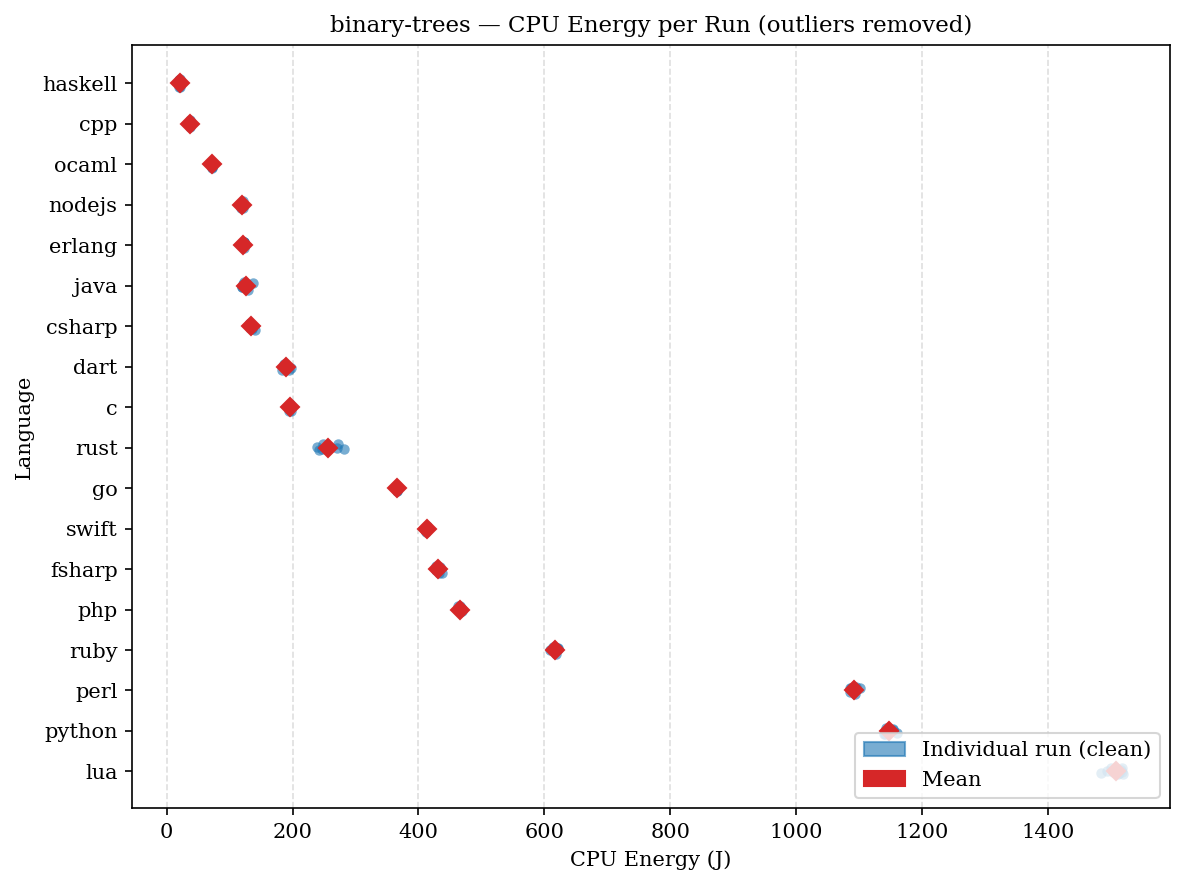

In [19]:
order = bt_means[COL_CPU_E].sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(8, 6))
sns.stripplot(
    data=bt_runs, x=COL_CPU_E, y='language', order=order,
    jitter=True, alpha=0.6, size=5, color='#1f77b4', ax=ax,
)
for i, lang in enumerate(order):
    ax.plot(bt_means.loc[lang, COL_CPU_E], i, marker='D', color='#d62728', markersize=6, zorder=5)

ax.legend(
    handles=[
        mpatches.Patch(color='#1f77b4', alpha=0.6, label='Individual run (clean)'),
        mpatches.Patch(color='#d62728', label='Mean'),
    ],
    loc='lower right',
)
ax.set_xlabel(f'CPU Energy ({unit(COL_CPU_E)})')
ax.set_ylabel('Language')
ax.set_title('binary-trees — CPU Energy per Run (outliers removed)')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
save('stripplot_cpu_energy')

---
## 3. Ranked bar — CPU Energy (main thesis chart)

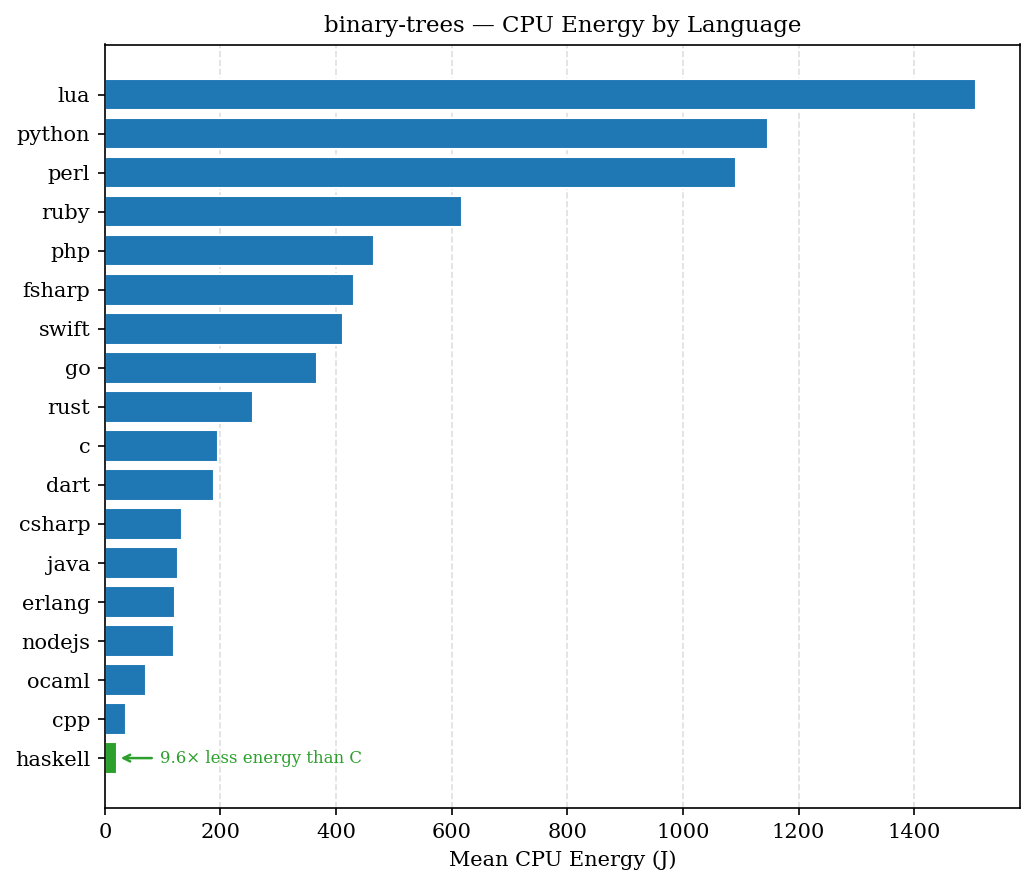

In [20]:
means = bt_means.sort_values(COL_CPU_E)

fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#2ca02c'] + ['#1f77b4'] * (len(means) - 1)
ax.barh(means.index, means[COL_CPU_E], color=colors, edgecolor='white')

haskell_val = means.loc['haskell', COL_CPU_E]
c_val       = means.loc['c',       COL_CPU_E]
ax.annotate(
    f'{c_val / haskell_val:.1f}× less energy than C',
    xy=(haskell_val, means.index.tolist().index('haskell')),
    xytext=(haskell_val + means[COL_CPU_E].max() * 0.05, means.index.tolist().index('haskell')),
    fontsize=8, color='#2ca02c', va='center',
    arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=1.2),
)

ax.set_xlabel(f'Mean CPU Energy ({unit(COL_CPU_E)})')
ax.set_title('binary-trees — CPU Energy by Language')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
save('bar_cpu_energy')

---
## 4. Multi-metric comparison (normalised to Haskell)

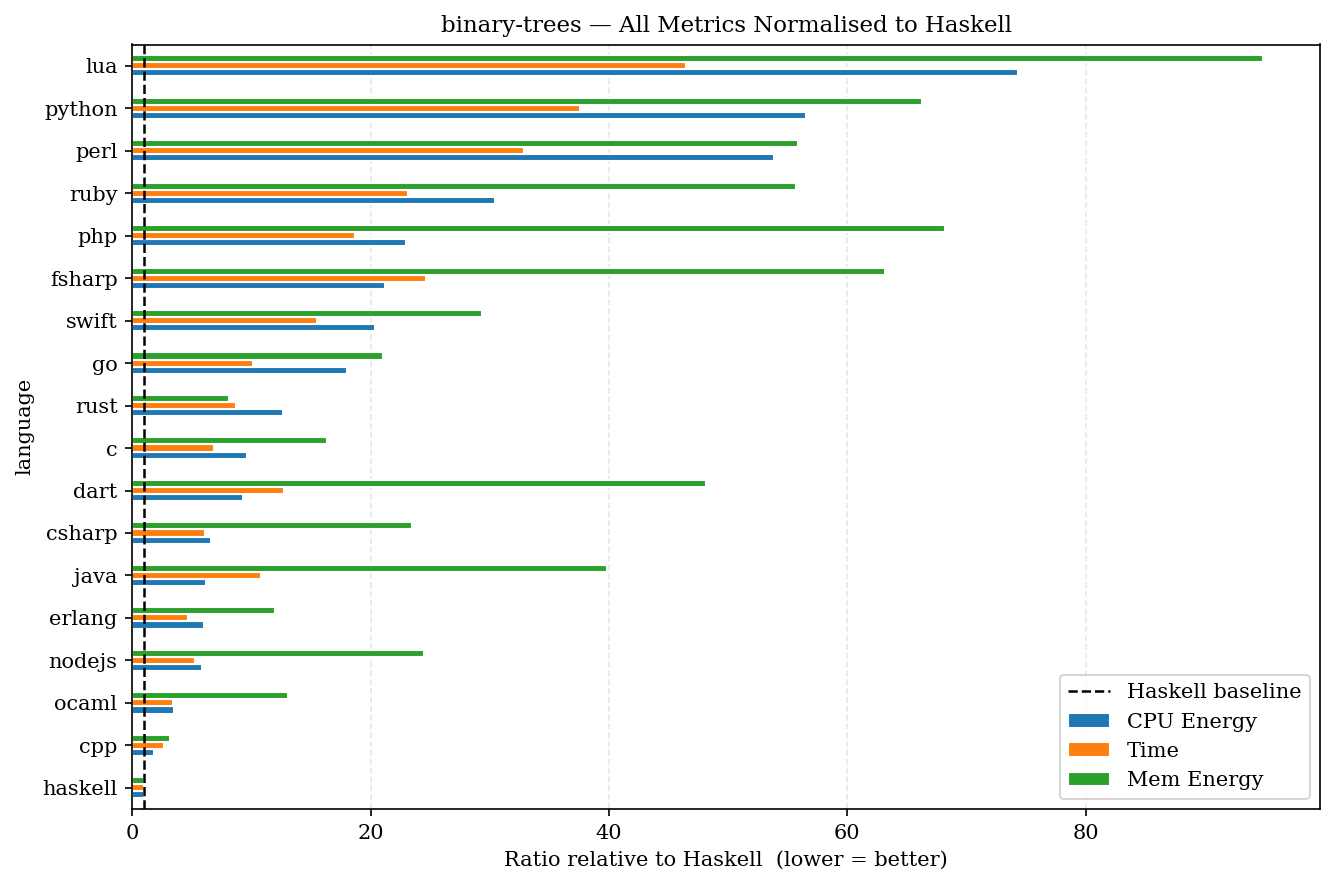

In [21]:
subset = means[[COL_CPU_E, COL_TIME, COL_MEM_E]]
ratio = subset.div(subset.loc['haskell'])
ratio.columns = ['CPU Energy', 'Time', 'Mem Energy']

fig, ax = plt.subplots(figsize=(9, 6))
ratio.plot(kind='barh', ax=ax, edgecolor='white')
ax.axvline(1.0, color='black', linewidth=1.2, linestyle='--', label='Haskell baseline')
ax.set_xlabel('Ratio relative to Haskell  (lower = better)')
ax.set_title('binary-trees — All Metrics Normalised to Haskell')
ax.legend(loc='lower right')
ax.xaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
save('normalised')

---
## 5. Energy vs. Time scatter

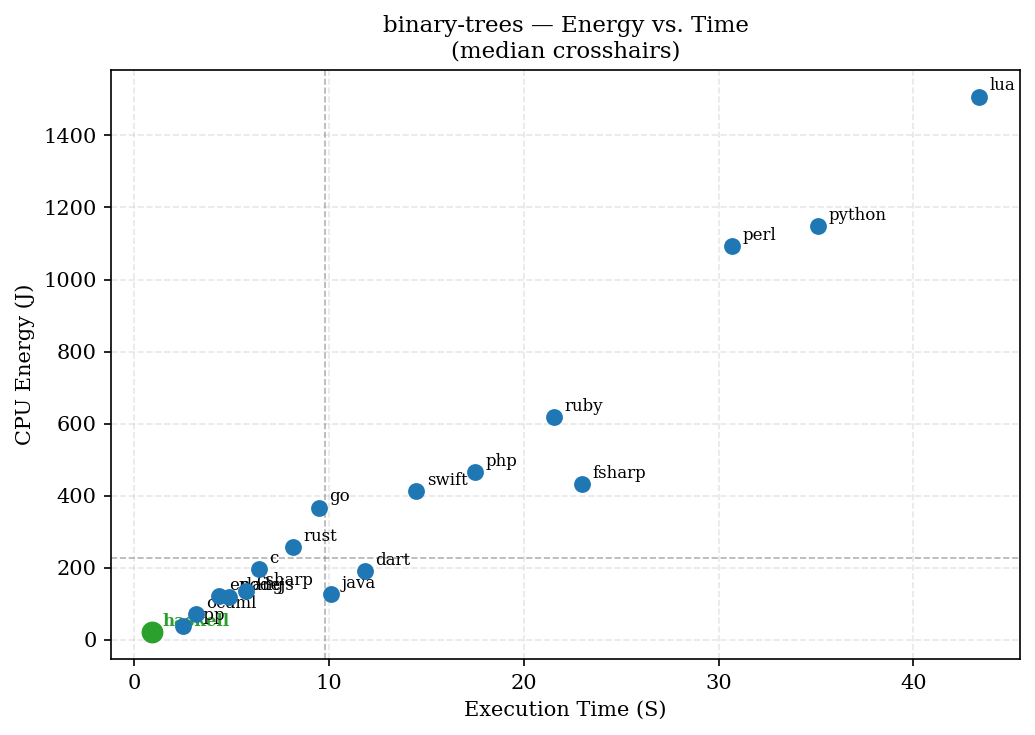

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))

for lang, row in means.iterrows():
    color = '#2ca02c' if lang == 'haskell' else '#1f77b4'
    size  = 90        if lang == 'haskell' else 50
    ax.scatter(row[COL_TIME], row[COL_CPU_E], color=color, s=size, zorder=3)
    ax.annotate(
        lang,
        (row[COL_TIME], row[COL_CPU_E]),
        textcoords='offset points', xytext=(5, 3), fontsize=8,
        color='#2ca02c' if lang == 'haskell' else 'black',
        fontweight='bold' if lang == 'haskell' else 'normal',
    )

ax.axvline(means[COL_TIME].median(),    color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(means[COL_CPU_E].median(),   color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

ax.set_xlabel(f'Execution Time ({unit(COL_TIME)})')
ax.set_ylabel(f'CPU Energy ({unit(COL_CPU_E)})')
ax.set_title('binary-trees — Energy vs. Time\n(median crosshairs)')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
save('scatter_energy_vs_time')

---
## 6. Summary table

In [23]:
summary = means[[COL_CPU_E, COL_TIME, COL_MEM_E, COL_CARBON]].copy()
summary.columns = [
    f'CPU Energy ({unit(COL_CPU_E)})',
    f'Time ({unit(COL_TIME)})',
    f'Mem Energy ({unit(COL_MEM_E)})',
    f'CPU Carbon ({unit(COL_CARBON)})',
]
summary.round(4)

,CPU Energy (J),Time (S),Mem Energy (J),CPU Carbon (G)
language,,,,
haskell,20.2946,0.9339,0.4352,0.0019
cpp,37.1395,2.5180,1.3698,0.0034
ocaml,71.4755,3.1603,5.6836,0.0066
nodejs,119.1707,4.8866,10.6469,0.0111
erlang,121.6393,4.3575,5.2330,0.0113
java,125.7048,10.0898,17.3290,0.0117
csharp,134.0891,5.7236,10.2146,0.0124
dart,189.3620,11.8573,20.9352,0.0176
c,195.4526,6.3988,7.1125,0.0181
